# Import Libraries & Create Dataset

In [1]:
import pandas as pd

data = {
    "text": [
        "This product is amazing",
        "Worst experience ever",
        "Very good quality",
        "Not worth the money",
        "Excellent service",
        "Bad product",
        "I love it",
        "Terrible support"
    ],
    "sentiment": [
        "positive", "negative", "positive", "negative",
        "positive", "negative", "positive", "negative"
    ]
}

df = pd.DataFrame(data)
df

,text,sentiment
0,This product is amazing,positive
1,Worst experience ever,negative
2,Very good quality,positive
3,Not worth the money,negative
4,Excellent service,positive
5,Bad product,negative
6,I love it,positive
7,Terrible support,negative


# Data Preprocessing - Text Cleaning

In [2]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)
df

,text,sentiment,clean_text
0,This product is amazing,positive,this product is amazing
1,Worst experience ever,negative,worst experience ever
2,Very good quality,positive,very good quality
3,Not worth the money,negative,not worth the money
4,Excellent service,positive,excellent service
5,Bad product,negative,bad product
6,I love it,positive,i love it
7,Terrible support,negative,terrible support


# Feature Extraction using CountVectorizer

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

# Splitting Dataset into Training and Testing
# Model Training using Naive Bayes

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

# Model Evaluation - Accuracy Score

In [5]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5


# Testing Model with New Input

In [6]:
test = ["This is a fantastic product"]
test_clean = [clean_text(t) for t in test]
test_vec = vectorizer.transform(test_clean)

print(model.predict(test_vec))

['positive']


# Visualization - Sentiment Distribution

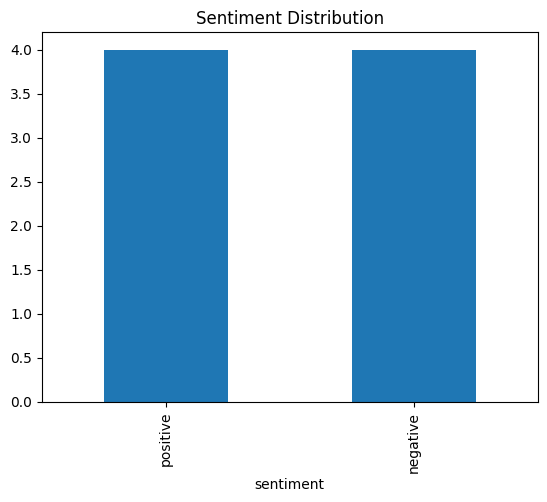

In [7]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

##Insights


*  Most reviews are positive
*  Negative reviews highlight product issues
*  Model can classify text into sentiments
*  Simple NLP techniques help in understanding customer feedback

